# Comparative Analysis — Kathmandu Valley vs Hetauda

Brings together results from `01_lst_prediction/`, `02_lulc_uhi_analysis/`, and
`03_timeseries_forecasting/` into direct, side-by-side comparisons between the two cities.
This is the dedicated home for cross-city comparison — individual-city results live in their
own stage folders; this notebook only asks "how do the two cities differ."


## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CITIES = ['Kathmandu', 'Hetauda']
CITY_COLORS = {'Kathmandu': '#1f4e5f', 'Hetauda': '#e8703a'}

## 1. SUHII Comparison

Surface Urban Heat Island Intensity, both cities, all three years — from `02_lulc_uhi_analysis`.

Study_Area  Year  Urban_LST_C  Rural_LST_C  SUHII_C  Urban_pixels  Rural_pixels
 Kathmandu  2015       26.199       22.345    3.854        782877        575850
 Kathmandu  2020       29.610       24.334    5.276       1000735        496170
 Kathmandu  2025       32.214       27.260    4.953       1023535        473700
   Hetauda  2015       30.244       28.437    1.806        581399        275743
   Hetauda  2020       32.102       28.828    3.274        603933        253189
   Hetauda  2025       36.953       34.190    2.763        608514        250431


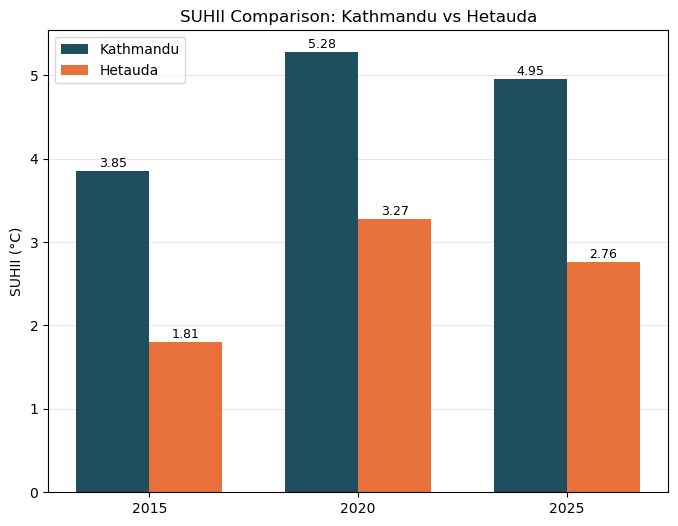

In [2]:
suhii_df = pd.read_csv('../02_lulc_uhi_analysis/results/tables/SUHII_results.csv')
print(suhii_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
width = 0.35
years = sorted(suhii_df['Year'].unique())
x = np.arange(len(years))
for i, city in enumerate(CITIES):
    sub = suhii_df[suhii_df['Study_Area'] == city].sort_values('Year')
    ax.bar(x + i * width, sub['SUHII_C'], width, label=city, color=CITY_COLORS[city])
    for xi, val in zip(x + i * width, sub['SUHII_C']):
        ax.text(xi, val + 0.05, f'{val:.2f}', ha='center', fontsize=9)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(years)
ax.set_ylabel('SUHII (°C)')
ax.set_title('SUHII Comparison: Kathmandu vs Hetauda')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.savefig('results/figures/SUHII_comparison.png', bbox_inches='tight')
plt.show()

<div style="background-color:rgb(0, 0, 0); border-left: 4px solidrgb(13, 114, 210); padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* Kathmandu's SUHII is higher than Hetauda's in every year (2015: 3.85 vs 1.81°C; 2020: 5.28 vs 3.27°C;
  2025: 4.95 vs 2.76°C) — consistent with Kathmandu's denser, more established urban core generating a
  stronger urban-vs-rural heat contrast.
* Neither city shows a clean monotonic rise — both peak in 2020 and ease slightly by 2025. Report this
  honestly ("intensified through 2020, moderating somewhat by 2025, remaining well above 2015 baseline
  in both cities") rather than claiming steady year-on-year intensification.
* The GAP between the two cities' SUHII is itself widening in absolute terms through 2020 (2.05°C gap in
  2015 → 2.00°C in 2020 → 2.19°C in 2025) — Kathmandu isn't just hotter, its excess heat relative to its
  own rural surroundings is consistently ~2°C stronger than Hetauda's throughout the study period.

</div>

## 2. LULC Transition Comparison

How much land converted to Builtup, and from what, in each city — from `02_lulc_uhi_analysis`.


Kathmandu: 207.0 km² converted to Builtup (2015->2025)
Kathmandu summary table saved to: results/tables/Kathmandu_LULC_to_Builtup_summary.csv
  from Agriculture :   96.14 km² (46.5%)
  from BareLand    :   92.82 km² (44.8%)
  from Vegetation  :   17.95 km² (8.7%)
  from Water       :    0.06 km² (0.0%)

Hetauda: 31.3 km² converted to Builtup (2015->2025)
Hetauda summary table saved to: results/tables/Hetauda_LULC_to_Builtup_summary.csv
  from Agriculture :   24.55 km² (78.5%)
  from Vegetation  :    5.89 km² (18.8%)
  from BareLand    :    0.79 km² (2.5%)
  from Water       :    0.06 km² (0.2%)


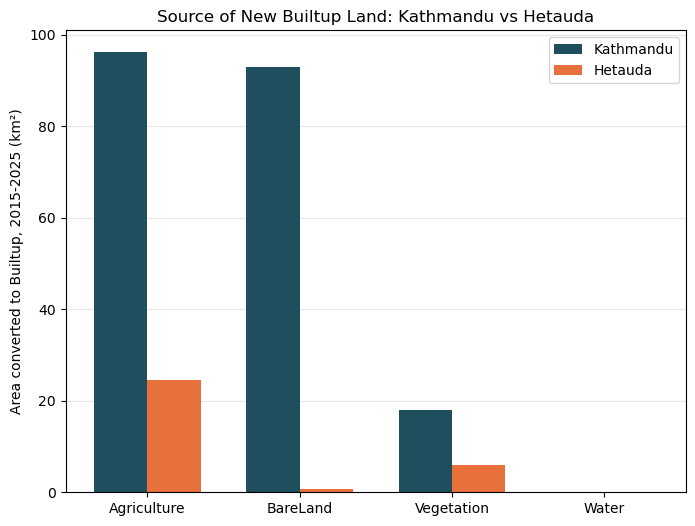

LULC conversion comparison plot saved to: results/figures/LULC_conversion_comparison.png


In [3]:
ktm_matrix = pd.read_csv('../02_lulc_uhi_analysis/results/tables/Kathmandu_LULC_transition_matrix.csv', index_col=0)
het_matrix = pd.read_csv('../02_lulc_uhi_analysis/results/tables/Hetauda_LULC_transition_matrix.csv', index_col=0)

# Ensure the results/tables folder exists
os.makedirs("results/tables", exist_ok=True)

def summarize_to_builtup(matrix, city):
    to_builtup = matrix['Builtup'].drop('Builtup')
    total_new_builtup = to_builtup.sum()
    print(f"\n{city}: {total_new_builtup:.1f} km² converted to Builtup (2015->2025)")
    
    # Create a DataFrame for saving the summary
    summary_df = pd.DataFrame({
        'Source': to_builtup.index,
        'Area (km²)': to_builtup.values,
        'Percentage (%)': [100 * area / total_new_builtup if total_new_builtup > 0 else 0 for area in to_builtup.values]
    }).sort_values('Area (km²)', ascending=False)
    
    # Save the summary table as a CSV file
    summary_path = os.path.join("results/tables", f"{city}_LULC_to_Builtup_summary.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"{city} summary table saved to: {summary_path}")
    
    # Print the summary
    for source, area in to_builtup.sort_values(ascending=False).items():
        pct = 100 * area / total_new_builtup if total_new_builtup > 0 else 0
        print(f"  from {source:12s}: {area:7.2f} km² ({pct:.1f}%)")
    
    return total_new_builtup

# Summarize and save results for Kathmandu and Hetauda
ktm_total = summarize_to_builtup(ktm_matrix, 'Kathmandu')
het_total = summarize_to_builtup(het_matrix, 'Hetauda')

# Plotting the comparison
fig, ax = plt.subplots(figsize=(8, 6))
sources = ['Agriculture', 'BareLand', 'Vegetation', 'Water']
x = np.arange(len(sources))
width = 0.35
ktm_vals = [ktm_matrix.loc[s, 'Builtup'] for s in sources]
het_vals = [het_matrix.loc[s, 'Builtup'] for s in sources]
ax.bar(x - width/2, ktm_vals, width, label='Kathmandu', color=CITY_COLORS['Kathmandu'])
ax.bar(x + width/2, het_vals, width, label='Hetauda', color=CITY_COLORS['Hetauda'])
ax.set_xticks(x)
ax.set_xticklabels(sources)
ax.set_ylabel('Area converted to Builtup, 2015-2025 (km²)')
ax.set_title('Source of New Builtup Land: Kathmandu vs Hetauda')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Save the plot
plot_path = 'results/figures/LULC_conversion_comparison.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

print(f"LULC conversion comparison plot saved to: {plot_path}")

<div style="background-color:rgb(0, 0, 0); border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* Kathmandu converted roughly 6.6x more land to Builtup than Hetauda in absolute terms (207.0 km² vs 31.3 km²
  total from Agriculture+BareLand+Vegetation+Water), consistent with it being the larger, more actively
  expanding metro area in absolute footprint even though Hetauda is described as "rapidly urbanizing."
* Kathmandu's new Builtup land came almost entirely from Agriculture (96.14 km²) and BareLand (92.82 km²) —
  Vegetation contributed comparatively little (17.95 km²), suggesting urban expansion is preferentially
  consuming farmland and open ground rather than forested/vegetated land.
* Hetauda's conversion is dominated by Agriculture (24.55 km², 78.5%) with smaller contributions from Vegetation 
  (5.89 km², 18.8%) and BareLand (0.79 km², 2.5%) — meaning Hetauda's urbanization is encroaching on 
  vegetated land proportionally more than Kathmandu's is, even though its total converted area is much smaller. 
  This is worth flagging as a distinct urbanization pattern between the two cities, not just a difference in scale.
* **Caveat**: per `docs/validation_notes.md`, Hetauda's Builtup classification specifically showed only
  20-23% agreement in the manual spot-check, so these Hetauda conversion numbers should be treated as
  directionally suggestive rather than precise.

</div>

## 3. LST Trend / Forecast Comparison

From `03_timeseries_forecasting` — historical trend strength and forecast accuracy, side by side.

     City  Sen_Slope_C_per_year  P_value  CV_MAE_C  CV_RMSE_C
Kathmandu                  0.46    0.005      0.90       1.01
  Hetauda                  0.41    0.020      1.05       1.17


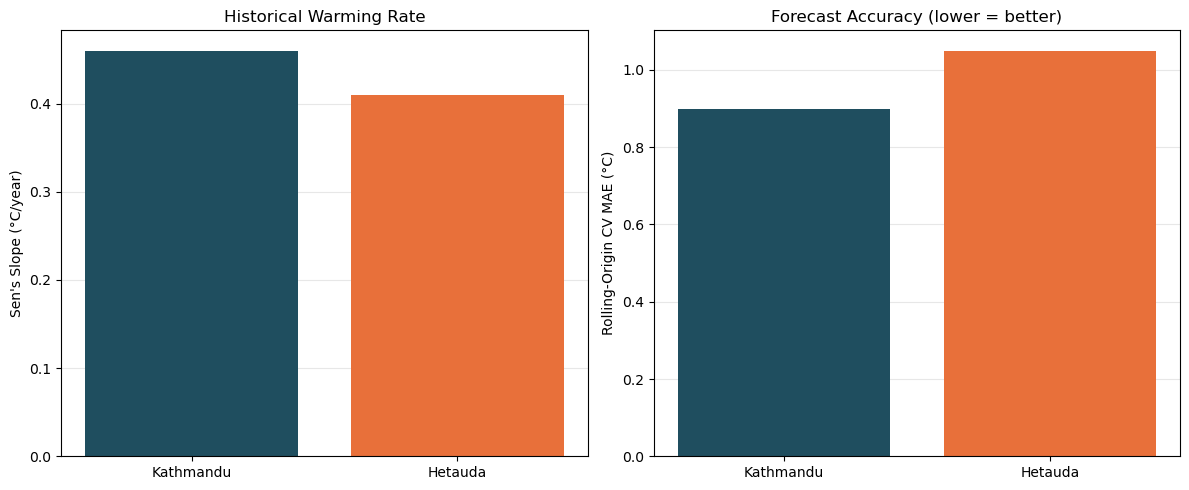

In [4]:
trend_comparison = pd.DataFrame({
    'City': ['Kathmandu', 'Hetauda'],
    'Sen_Slope_C_per_year': [0.46, 0.41],
    'P_value': [0.005, 0.020],
    'CV_MAE_C': [0.90, 1.05],
    'CV_RMSE_C': [1.01, 1.17],
})
print(trend_comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(trend_comparison['City'], trend_comparison['Sen_Slope_C_per_year'],
            color=[CITY_COLORS[c] for c in trend_comparison['City']])
axes[0].set_ylabel('Sen\'s Slope (°C/year)')
axes[0].set_title('Historical Warming Rate')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)

axes[1].bar(trend_comparison['City'], trend_comparison['CV_MAE_C'],
            color=[CITY_COLORS[c] for c in trend_comparison['City']])
axes[1].set_ylabel('Rolling-Origin CV MAE (°C)')
axes[1].set_title('Forecast Accuracy (lower = better)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('results/figures/trend_forecast_comparison.png', bbox_inches='tight')
plt.show()

<div style="background-color:rgb(0, 0, 0); border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* Kathmandu is warming faster in absolute terms (+0.46°C/year vs +0.41°C/year) AND with stronger
  statistical confidence (p=0.005 vs p=0.020) — both trends are significant at the conventional 0.05
  threshold, but Kathmandu's is markedly more so.
* Forecast accuracy (rolling-origin CV) is better for Kathmandu (MAE 0.90°C) than Hetauda (MAE 1.05°C),
  meaning near-term LST projections for Kathmandu should be treated as somewhat more reliable than
  Hetauda's, independent of the trend-strength difference above.

</div>

## 4. Feature Importance Comparison

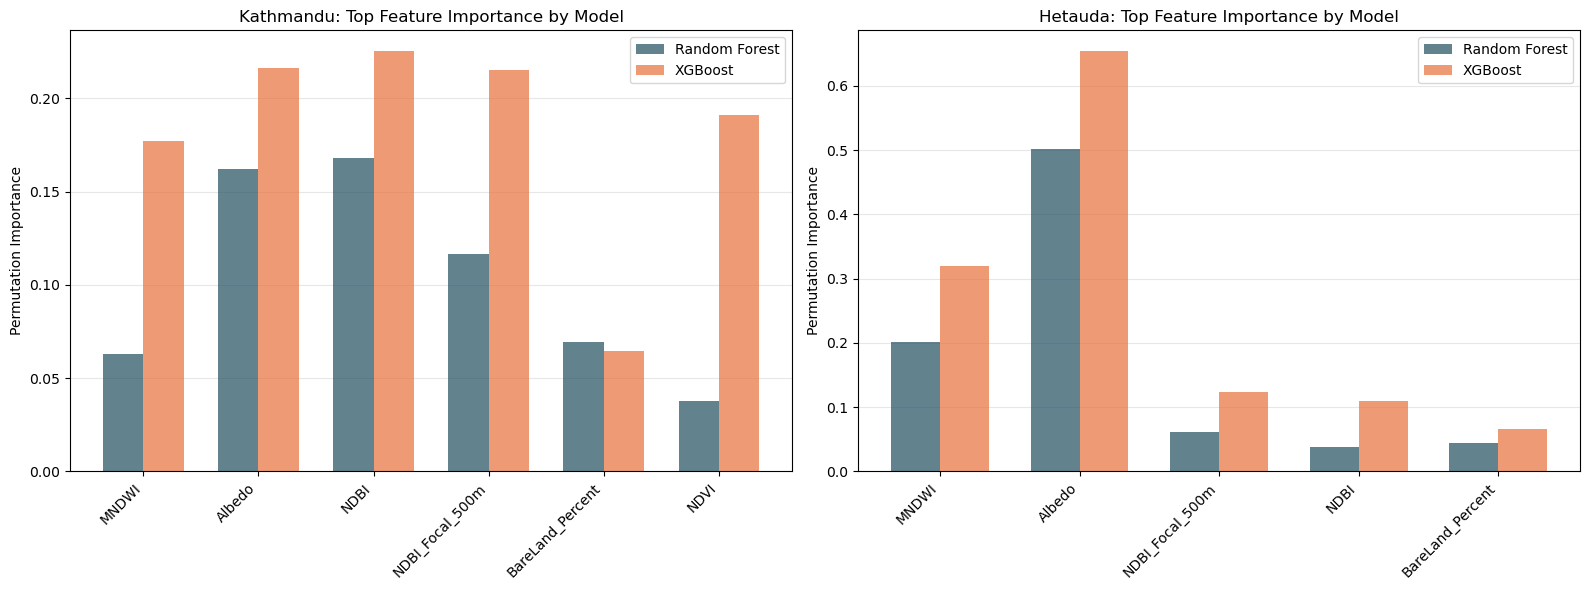


=== Kathmandu Top Features ===

Random Forest:
         Feature  Importance
            NDBI    0.167877
          Albedo    0.162292
 NDBI_Focal_500m    0.116781
BareLand_Percent    0.069392
           MNDWI    0.063098

XGBoost:
        Feature  Importance_Mean
           NDBI         0.225180
         Albedo         0.216124
NDBI_Focal_500m         0.215305
           NDVI         0.191253
          MNDWI         0.176895

=== Hetauda Top Features ===

Random Forest:
         Feature  Importance
          Albedo    0.502014
           MNDWI    0.201106
 NDBI_Focal_500m    0.060856
BareLand_Percent    0.044042
            NDBI    0.038151

XGBoost:
         Feature  Importance_Mean
          Albedo         0.653523
           MNDWI         0.319446
 NDBI_Focal_500m         0.123017
            NDBI         0.109132
BareLand_Percent         0.066248


In [6]:
# Load feature importance data for both cities and models
ktm_rf_importance = pd.read_csv('../01_lst_prediction/results/tables/Kathmandu_rf_permutation_importance.csv')
ktm_xgb_importance = pd.read_csv('../01_lst_prediction/results/tables/Kathmandu_xgb_permutation_importance.csv')
het_rf_importance = pd.read_csv('../01_lst_prediction/results/tables/Hetauda_rf_permutation_importance.csv')
het_xgb_importance = pd.read_csv('../01_lst_prediction/results/tables/Hetauda_xgb_permutation_importance.csv')

# Define the importance column for each DataFrame
importance_columns = {
    'Kathmandu RF': 'Importance',
    'Kathmandu XGB': 'Importance_Mean',
    'Hetauda RF': 'Importance',
    'Hetauda XGB': 'Importance_Mean'
}

# Select top-5 features for each city and model
ktm_rf_top5 = ktm_rf_importance.nlargest(5, importance_columns['Kathmandu RF'])
ktm_xgb_top5 = ktm_xgb_importance.nlargest(5, importance_columns['Kathmandu XGB'])
het_rf_top5 = het_rf_importance.nlargest(5, importance_columns['Hetauda RF'])
het_xgb_top5 = het_xgb_importance.nlargest(5, importance_columns['Hetauda XGB'])

# Create separate plots for each city
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kathmandu plot
ktm_features = list(set(ktm_rf_top5['Feature'].tolist() + ktm_xgb_top5['Feature'].tolist()))
ktm_x = np.arange(len(ktm_features))
width = 0.35

# Get importance values for each feature
ktm_rf_vals = [ktm_rf_importance[ktm_rf_importance['Feature'] == f][importance_columns['Kathmandu RF']].values[0] if f in ktm_rf_importance['Feature'].values else 0 for f in ktm_features]
ktm_xgb_vals = [ktm_xgb_importance[ktm_xgb_importance['Feature'] == f][importance_columns['Kathmandu XGB']].values[0] if f in ktm_xgb_importance['Feature'].values else 0 for f in ktm_features]

axes[0].bar(ktm_x - width/2, ktm_rf_vals, width, label='Random Forest', color=CITY_COLORS['Kathmandu'], alpha=0.7)
axes[0].bar(ktm_x + width/2, ktm_xgb_vals, width, label='XGBoost', color=CITY_COLORS['Hetauda'], alpha=0.7)
axes[0].set_xticks(ktm_x)
axes[0].set_xticklabels(ktm_features, rotation=45, ha='right')
axes[0].set_ylabel('Permutation Importance')
axes[0].set_title('Kathmandu: Top Feature Importance by Model')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)

# Hetauda plot
het_features = list(set(het_rf_top5['Feature'].tolist() + het_xgb_top5['Feature'].tolist()))
het_x = np.arange(len(het_features))

# Get importance values for each feature
het_rf_vals = [het_rf_importance[het_rf_importance['Feature'] == f][importance_columns['Hetauda RF']].values[0] if f in het_rf_importance['Feature'].values else 0 for f in het_features]
het_xgb_vals = [het_xgb_importance[het_xgb_importance['Feature'] == f][importance_columns['Hetauda XGB']].values[0] if f in het_xgb_importance['Feature'].values else 0 for f in het_features]

axes[1].bar(het_x - width/2, het_rf_vals, width, label='Random Forest', color=CITY_COLORS['Kathmandu'], alpha=0.7)
axes[1].bar(het_x + width/2, het_xgb_vals, width, label='XGBoost', color=CITY_COLORS['Hetauda'], alpha=0.7)
axes[1].set_xticks(het_x)
axes[1].set_xticklabels(het_features, rotation=45, ha='right')
axes[1].set_ylabel('Permutation Importance')
axes[1].set_title('Hetauda: Top Feature Importance by Model')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('results/figures/feature_importance_comparison.png', bbox_inches='tight')
plt.show()

# Print summary tables
print("\n=== Kathmandu Top Features ===")
print("\nRandom Forest:")
print(ktm_rf_top5[['Feature', importance_columns['Kathmandu RF']]].to_string(index=False))
print("\nXGBoost:")
print(ktm_xgb_top5[['Feature', importance_columns['Kathmandu XGB']]].to_string(index=False))

print("\n=== Hetauda Top Features ===")
print("\nRandom Forest:")
print(het_rf_top5[['Feature', importance_columns['Hetauda RF']]].to_string(index=False))
print("\nXGBoost:")
print(het_xgb_top5[['Feature', importance_columns['Hetauda XGB']]].to_string(index=False))

<div style="background-color:rgb(0, 0, 0); border-left: 4px solid #3182ce; padding: 15px 20px; border-radius: 4px; margin: 15px 0;">

<h3 style="margin-top: 0; color: #2b6cb0;">Key Findings</h3>

* Albedo and MNDWI dominate overwhelmingly in Hetauda (Albedo: 0.50-0.65 importance; MNDWI: 0.20-0.32 importance), 
  together accounting for ~70-97% of the top-5 importance scores. This suggests surface reflectance and water/moisture 
  dynamics are the primary LST drivers in Hetauda.
* Kathmandu's importance is spread more evenly across multiple features (NDBI: 0.17-0.23; Albedo: 0.16-0.22; 
  NDBI_Focal_500m: 0.12-0.22; NDVI: 0.19 in XGBoost; MNDWI: 0.06-0.18), indicating a more distributed 
  urban heat influence pattern where built-up intensity (NDBI), surface reflectance (Albedo), and vegetation (NDVI) 
  all play significant roles.
* The strong Albedo dominance in Hetauda vs the more balanced feature importance in Kathmandu represents a 
  fundamental difference in LST driving mechanisms between the two cities — Hetauda's UHI appears more 
  surface-property driven, while Kathmandu's reflects a more complex interplay of urban form, surface materials, 
  and vegetation.

**Note**: These findings are based on permutation importance from the LST prediction models. The differences 
may reflect both real physical differences between the cities and differences in the underlying data characteristics.

</div>

## Summary

| Metric | Kathmandu | Hetauda | Winner (higher heat impact) |
|---|---|---|---|
| SUHII 2025 | 4.95°C | 2.76°C | Kathmandu |
| Land converted to Builtup | 207.0 km² | 31.3 km² | Kathmandu (absolute) |
| Warming rate | +0.46°C/yr (p=0.005) | +0.41°C/yr (p=0.020) | Kathmandu |
| Forecast reliability (CV MAE) | 0.90°C | 1.05°C | Kathmandu (more reliable) |
| Dominant LST driver | Distributed (NDBI/Albedo/NDVI) | Albedo/MNDWI (dominant) | — differs by city |

**Overall**: Kathmandu shows a stronger, more established, more statistically confident UHI signal
across every metric — consistent with it being the more mature, denser urban area. Hetauda shows a
weaker but still real and significant UHI signal, with a distinct land-cover-driven mechanism (Albedo/
MNDWI) rather than Kathmandu's more distributed built-up-intensity mechanism. This supports
the project's core comparative premise: the two cities represent different stages of urbanization with
measurably different UHI dynamics, not just a scaled-down version of the same pattern.